# Week 3. Vacancy optimization and migration in graphene
## Exercise MMM 2026 - ETHZ - Weeks 2/3 - Daniele Passerone

In the present exercise and the one of Week 3, we will investigate the equilibrium structures of graphene as a periodic 2D lattice, as well as a vacancy (defect) diffusion mechanism. 
As a calculator we will use the code LAMMPS.
As an interaction potential we will use different directional bond potentials (classical) implemented in LAMMPS.
As minimization method for minima and transition states (elastic band) we will use BFGS and the FIRE MD-based algorithm (https://www.math.uni-bielefeld.de/~gaehler/papers/fire.pdf).
There is a paper where the same diffusion mechanism we study today is described with ab initio calculations: https://link.aps.org/doi/10.1103/PhysRevB.98.075439 . 

Find the paper directly here: https://drive.switch.ch/index.php/s/wJDW4SPsbB7OSwq/download and SI https://drive.switch.ch/index.php/s/MiNpSwtMO2UOnMT/download 


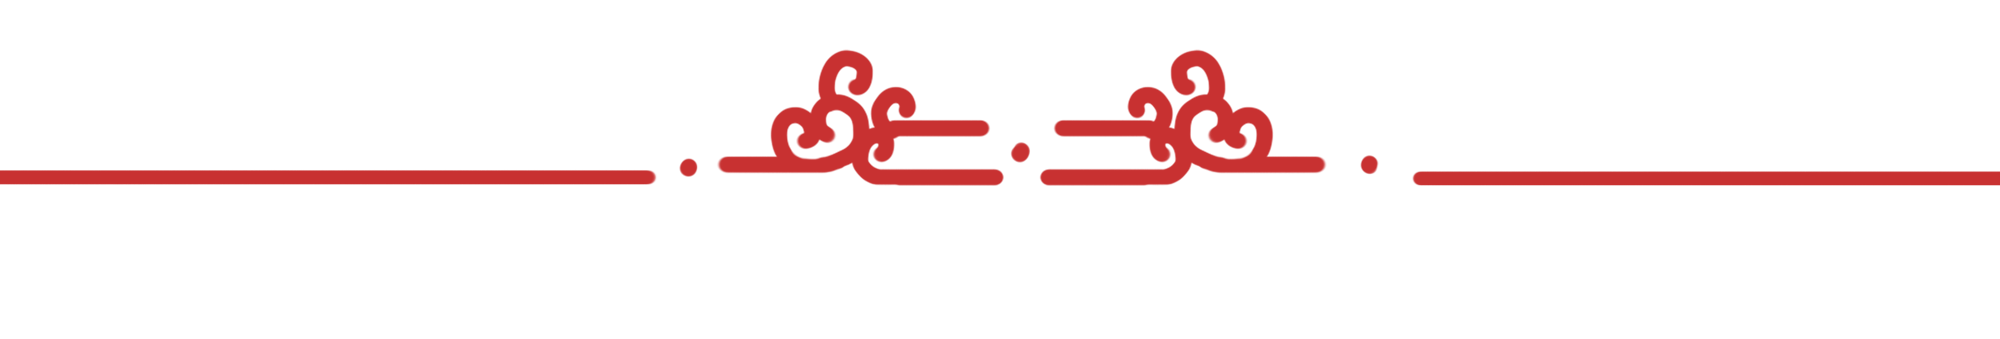

# PART 2: NUDGED ELASTIC BAND #

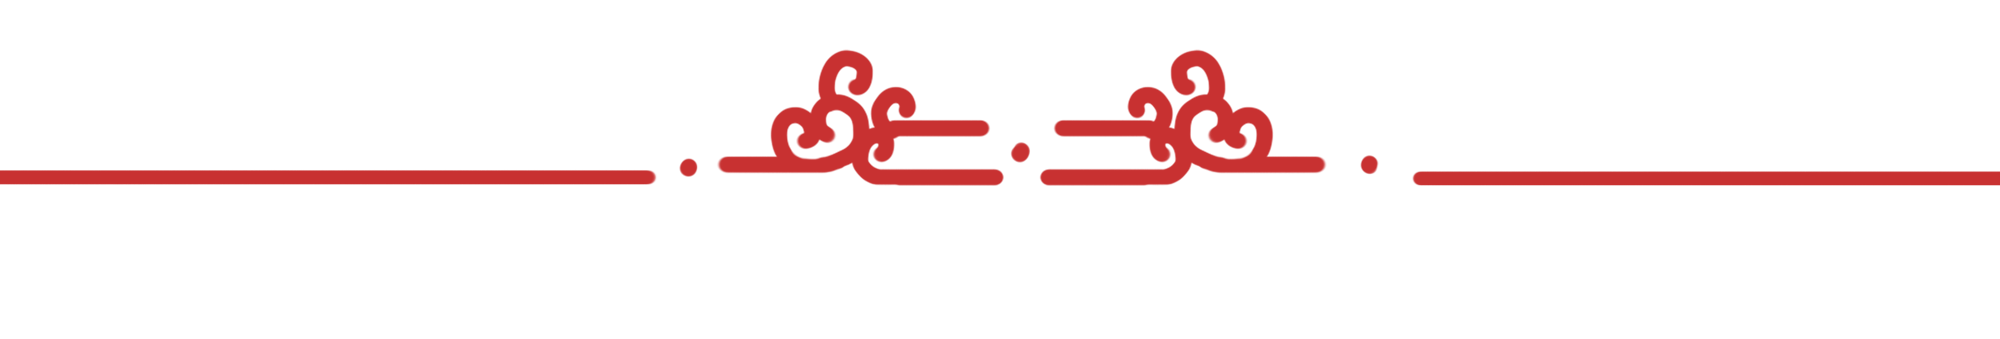

# Downloading relevant files from the switch repository


In [ ]:
!test -s CH.airebo || wget -O CH.airebo "https://drive.switch.ch/index.php/s/gPH1xNnZRAgv5IZ/download"
!test -s C.lcbop || wget -O C.lcbop "https://drive.switch.ch/index.php/s/OCxUFx3LLgnNn26/download"
!test -s SiC.tersoff || wget -O SiC.tersoff "https://drive.switch.ch/index.php/s/rWF5mEFuNGNbKTY/download"
!test -s SI_Babar_and_Kabir.pdf || wget -O SI_Babar_and_Kabir.pdf "https://drive.switch.ch/index.php/s/MiNpSwtMO2UOnMT/download"
!test -s Babar_and_Kabir.pdf || wget -O Babar_and_Kabir.pdf "https://drive.switch.ch/index.php/s/wJDW4SPsbB7OSwq/download"

# What will we learn today


* We will see with two separate force fields that the diffusion of the vacancy suffers from a bad description of the systems by ALL force fields.
* In particular, the putative transition state is a deep minimum with the **lcbop** potential
* We will compute the energies along the barrier with an ab initio description, showing that the problem is solved and a "true barrier" is found.

## Inspiration from the figures of paper

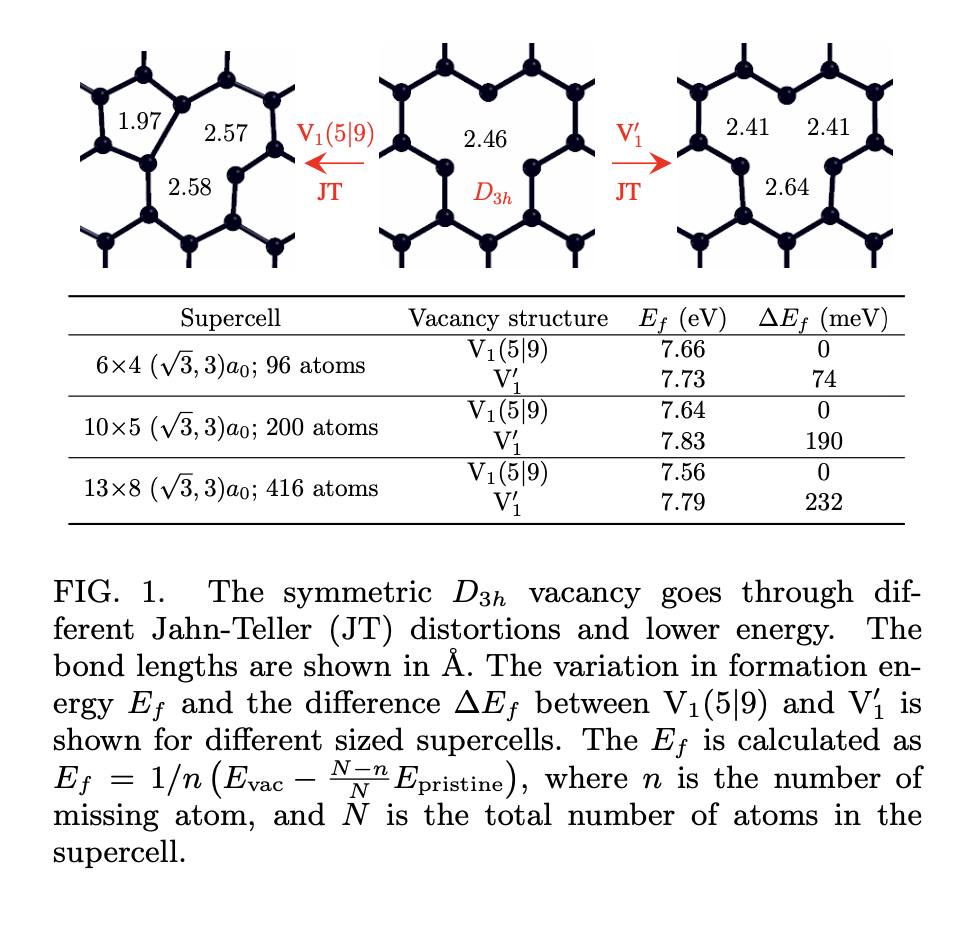

Note that the V1(5|9) (left) is the most stable state.

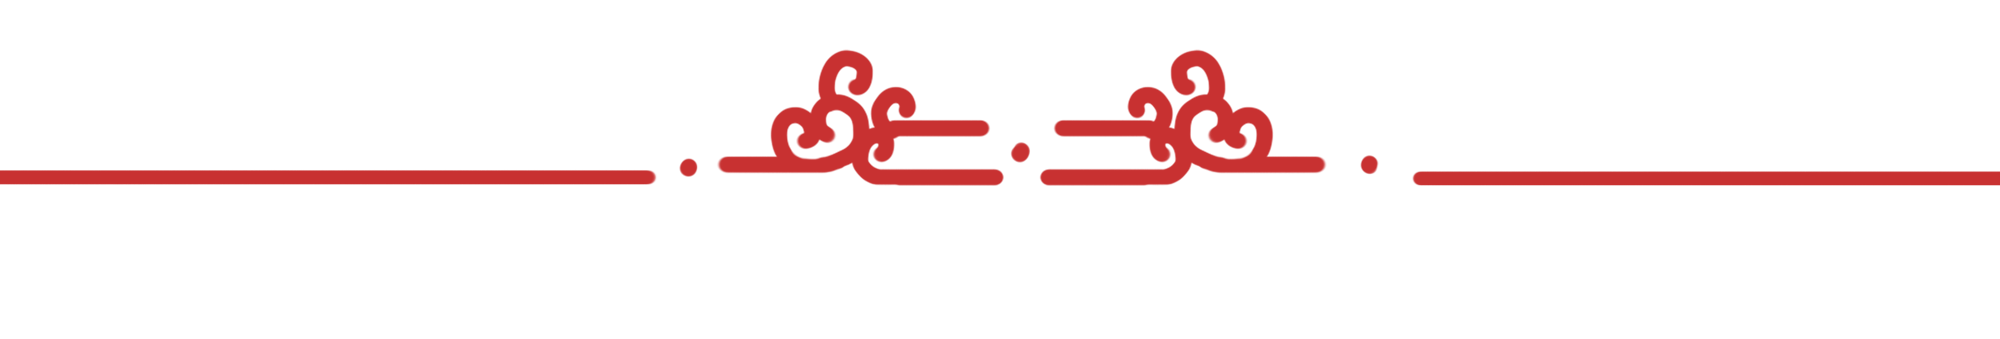

# Visualisation functions

In [ ]:
def view_structure(structure, nview=None, nmobile=None, distances=None):
    
    import numpy as np
    import ipywidgets as widgets

    if nview is None:
        nview = len(structure)
        
    if nmobile is None: 
        nmobile = len(structure)
        
        
    # Extract title if present
    title = structure.info.get("title", "Structure")

    title_widget = widgets.HTML(
        f"<h3 style='margin:0; padding:4px'>{title}</h3>"
    )
        
    out = widgets.Output()
    distbox = widgets.Output()
    
    

    # structure shortened to avoid bonds bug for large structures
    mystructure = structure[list(range(nview))]
    

    t = nv.ASEStructure(mystructure)
    w = nv.NGLWidget(t, gui=True)
    w.clear_representations()
    w.add_unitcell()

    # representations
    w.add_representation('label', label_type='atomindex', color='black', scale=1.5)
    w.add_representation('spacefill', selection=list(range(nmobile)), color="blue", radius=0.3)
    w.add_representation('licorice', selection=list(range(nmobile)), color="blue", multipleBond=True)
    w.add_representation('spacefill', selection=list(range(nmobile, nview)), color="red", radius=0.3)
    w.add_representation('licorice', selection=list(range(nview)), color="red", radius=0.1, multipleBond=True)

    # callback pick
    def on_pick(change):
        with out:
            out.clear_output()
            print("Picked atom index:", change.new)

        # updated on click
        if distances is not None:
            update_distances()

    w.observe(on_pick, names='picked')

    # distance panel
    if distances is not None:

        def update_distances():
            atoms = mystructure

            with distbox:
                distbox.clear_output()
                print("Distances:")
                for (i, j) in distances:
                    d = np.linalg.norm(atoms.positions[i] - atoms.positions[j])
                    print(f"{i}-{j}: {d:.2f} Å")

        # initialize
        update_distances()

    return widgets.VBox([title_widget, w, out, distbox])


In [ ]:
def view_trajectory(trajectory, nview=None, nmobile=None, distances=None):

    import numpy as np
    import ipywidgets as widgets

    if nview is None:
        nview = len(trajectory[-1])
    if nmobile is None:
        nmobile = len(trajectory[-1])
        
    # Extract title if present
    title = "Trajectory: " + trajectory[0].info.get("title", "Structure")

    title_widget = widgets.HTML(
        f"<h3 style='margin:0; padding:4px'>{title}</h3>"
    )
              

    out = widgets.Output()
    distbox = widgets.Output()

    # Structure is shortened to make only nview atoms visible.
    
    mytrajectory = [frame[list(range(nview))] for frame in trajectory]


    t2 = nv.ASETrajectory(mytrajectory)
    w2 = nv.NGLWidget(t2, gui=True)
    w2.clear_representations()
    w2.add_unitcell()

    # representation
    w2.add_representation('label', label_type='atomindex', color='black', scale=1.5)
    w2.add_representation('spacefill', selection=list(range(nmobile)), color="blue", radius=0.3)
    w2.add_representation('licorice', selection=list(range(nmobile)), color="blue", multipleBond=True)
    w2.add_representation('spacefill', selection=list(range(nmobile, nview)), color="red", radius=0.3)
    w2.add_representation('licorice', selection=list(range(nview)), color="red", radius=0.1, multipleBond=True)
#    w2.add_representation('ball+stick', selection=list(range(nview)), color="red", radius=0.1, multipleBond=False)
    # callback pick
    def on_pick(change):
        with out:
            out.clear_output()
            print("Picked atom index:", change.new)

    w2.observe(on_pick, names='picked')

    # distance panel (optional)
    if distances is not None:

        def update_distances(change=None):
            frame = w2.frame
            atoms = mytrajectory[frame]

            with distbox:
                distbox.clear_output()
                print("Distances frame", frame)
                for (i, j) in distances:
                    d = np.linalg.norm(atoms.positions[i] - atoms.positions[j])
                    print(f"{i}-{j}: {d:.2f} Å")

        update_distances()
        w2.observe(update_distances, names='frame')

    return widgets.VBox([title_widget,w2, out, distbox])



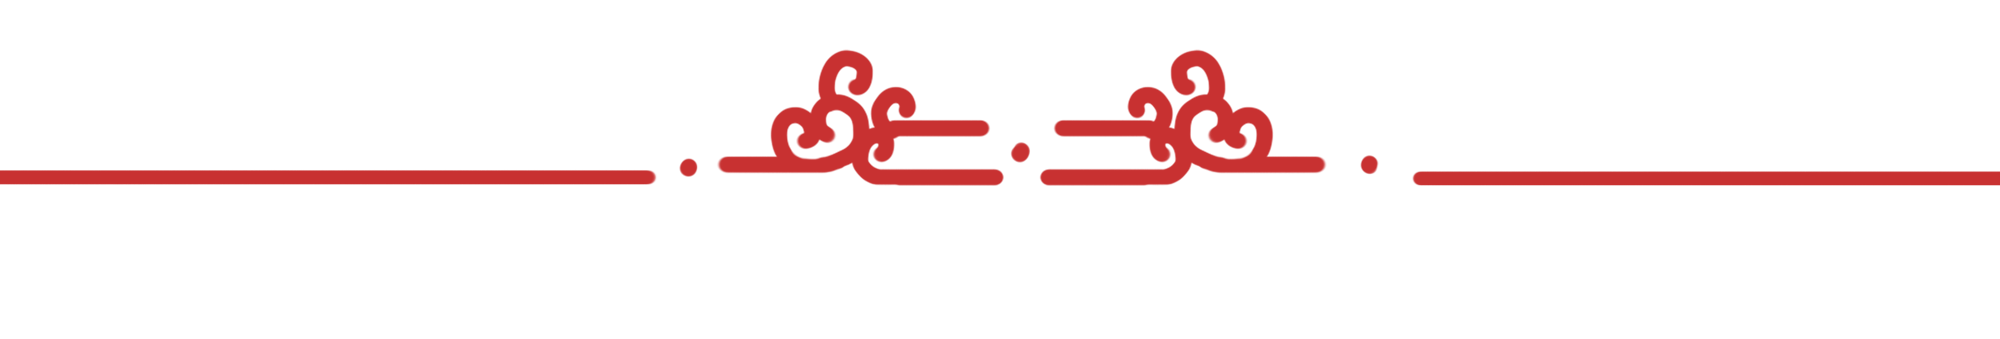

# Loading the graphene sheet from last time

In [ ]:
import numpy as np
from ase import Atoms
from ase.io import read,write
from ase.calculators.lammpsrun import LAMMPS
from ase.calculators.cp2k import CP2K
from ase.optimize import BFGS
from ase.build import graphene
import nglview as nv

# Copying xyz files from previous exercise

!test -s graph_0.xyz || cp ../Exercise_02*/graph_0.xyz .
!test -s d3h_a.xyz || cp ../Exercise_02*/d3h_a.xyz .
!test -s d3h_b.xyz || cp ../Exercise_02*/d3h_b.xyz .
!test -s 59_a.xyz || cp ../Exercise_02*/59_a.xyz .
!test -s 59_b.xyz || cp ../Exercise_02*/59_b.xyz .

graph_0 = read("graph_0.xyz")

N = len(graph_0)
all_indices = list(range(N))
if (N > 500):
    nviewmax = 500
else:
    nviewmax = N


In [ ]:
#
# Extract moving atoms from the loaded structure
#

lastindex_0 = N - len(graph_0.constraints[0].index)

print ("Number of moving atoms ", lastindex_0)

graph_0.center()
view_structure(graph_0,nmobile=lastindex_0,nview=nviewmax)

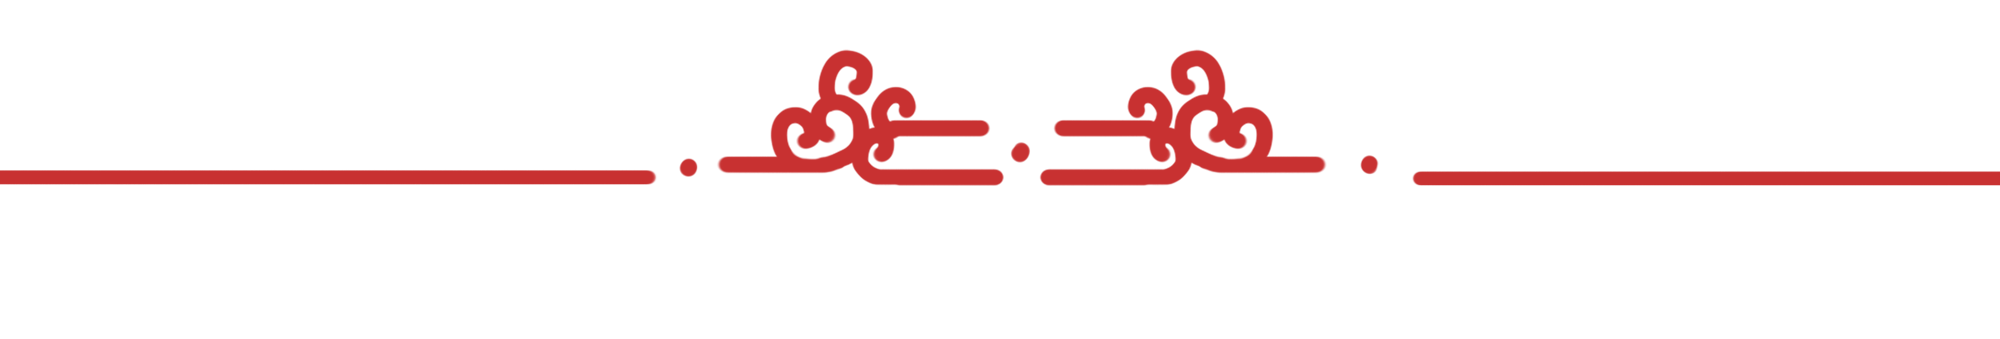

#  Calculators
We define a few calculators to extract the potential energy of the system and the forces among atoms.
This is basically used to "optimize the structure", namely getting to zero all derivatives upon atom displacement.
A force field allows to predict the forces between atoms "forgetting" the coordinates of electrons, and only keeping the nuclear ones.

In [ ]:
#
# the "active" calculator is the one called by the function "make_calc"
#

from ase.calculators.lammpslib import LAMMPSlib

def make_calc_tersoff():
    return LAMMPSlib(
        lmpcmds=[
            "pair_style tersoff",
            "pair_coeff * * SiC.tersoff C"
        ],
        log_file="lammps.log",
        keep_alive=True
    )


def make_calc_lcbop():
    return LAMMPSlib(
        lmpcmds=[
            "pair_style lcbop",
            "pair_coeff * * C.lcbop C"
        ],
        log_file="lammps.log",
        keep_alive=True
    )

def make_calc_airebo():
    return LAMMPSlib(
        lmpcmds=[
            "pair_style airebo 5.0",
            "pair_coeff * * CH.airebo C"
        ],
        log_file="lammps.log",
        keep_alive=True
    )


def make_calc():
    return make_calc_lcbop()





In [ ]:

#
# the graphene sheet gets the calculator. We compute potential energy in eV!
#

graph_0.calc = make_calc()
energy_0 = graph_0.get_potential_energy()
energy_atom_0 = graph_0.get_potential_energy()/N

print ("Total potential energy, perfect graphene sheet: ",energy_0," eV")
print ("Energy per atom, perfect graphene sheet: ",energy_atom_0," eV")



In [ ]:
#
# Definitions for printing during the optimization
#

def print_status(atoms, fmax_target):
    step = opt.get_number_of_steps()

    E = atoms.get_potential_energy()
    F = atoms.get_forces()
    Fnorm = np.linalg.norm(F)
    Fmax = np.max(np.linalg.norm(F, axis=1))

    if step % 10 == 0:
        print(f"Step {step:4d} | E = {E: .6f} eV | Fmax = {Fmax:.4f} | |grad| = {Fnorm:.4f}")

    if Fmax < fmax_target:
        print(f"Converged at step {step}: Fmax = {Fmax:.4f} < fmax = {fmax_target}")


In [ ]:
# After optimizing graphene, we get the pristine energy as the converged energy per atom

e_pristine = graph_0.get_potential_energy()/N

print ("Optimized energy per atom for the pristine flat graphene sheet ",e_pristine," eV")

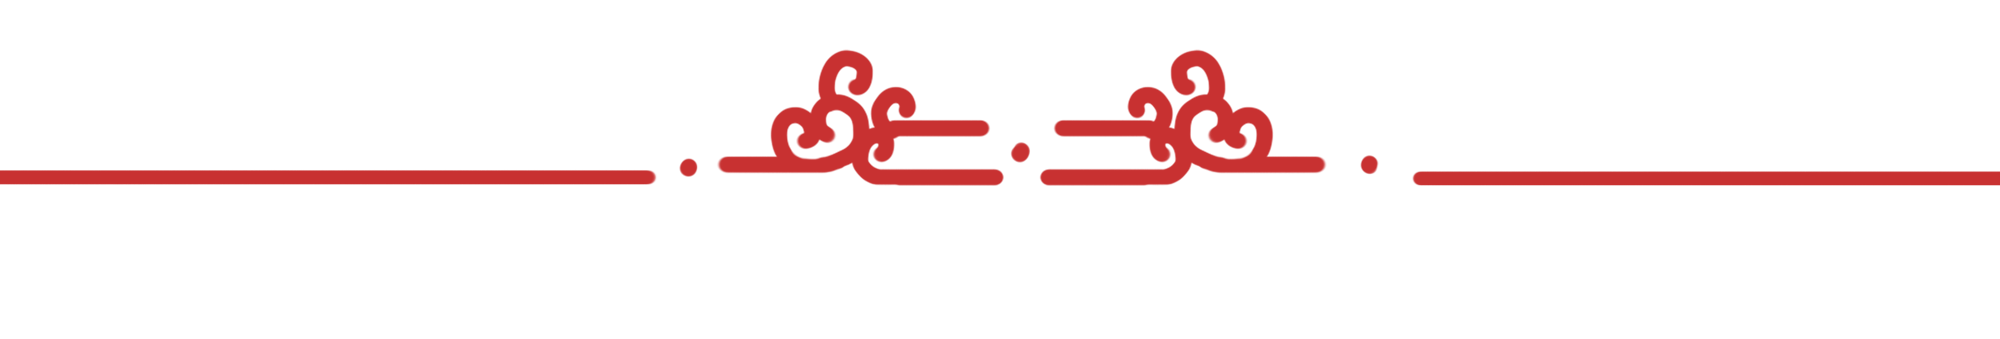

# Load graphene vacancy structures. 

We already optimized them last time with "some" potential, we verify the minima for "security reasons" today. 



In [ ]:
#
# If you want a flat system, set this to "True"
#

do_flat = False



graph_59_a = read("59_a.xyz")
graph_59_a.calc = make_calc()
graph_59_b = read("59_b.xyz")
graph_59_b.calc = make_calc()
graph_d3h_a = read("d3h_a.xyz")
graph_d3h_a.calc = make_calc()
graph_d3h_b = read("d3h_b.xyz")
graph_d3h_b.calc = make_calc()


lastindex_v = lastindex_0 - 1

#
# PARAMETERS FOR ALL OPTIMIZATIONS
#


#
# displacement of atom 0 before optimization
#
zmin = 0.5
zmax = 0.5

#
# rattling the moving atoms
#
mystdev = 0.0


#
# convergence criterion for bfgs
#
myfmax = 0.05

In [ ]:
#
# do a flat system?
#

if (do_flat):
    graph_59_a.positions[:,2] = graph_59_a.positions[N-2,2]
print(graph_59_a.cell)
view_structure(graph_59_a)


In [ ]:
#
# do a flat system?
#

if (do_flat):
    graph_59_b.positions[:,2] = graph_59_b.positions[N-2,2]
print(graph_59_b.cell)
view_structure(graph_59_b)


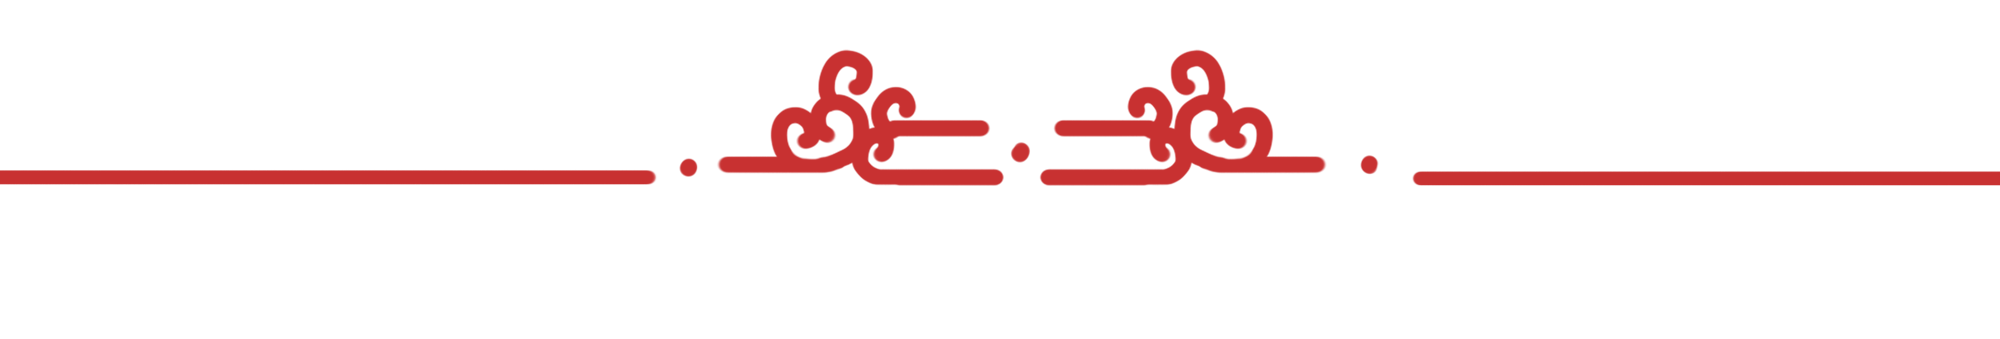

# STATE D3H (converging to a symmetric configuration)

## Site a, D3H

In [ ]:
#
# Optimize the geometry of vacancy D3H, site a
#



opt = BFGS(graph_d3h_a, logfile="bfgs_full.log", trajectory="graphene_d3h_a_opt.traj")
opt.attach(print_status, interval=1, atoms=graph_d3h_a, fmax_target=myfmax)
opt.run(fmax=myfmax)

print ("Final energy d3h_a ",graph_d3h_a.get_potential_energy()," eV")

mytraj = read("graphene_d3h_a_opt.traj",":")


In [ ]:

evac_d3h_a = (graph_d3h_a.get_potential_energy()-(N-1)*e_pristine)
print ("Vacancy formation energy d3h_a: ",evac_d3h_a," eV")

## Site b, D3H

In [ ]:

opt = BFGS(graph_d3h_b, logfile="bfgs_full.log", trajectory="graphene_d3h_b_opt.traj")
opt.attach(print_status, interval=1, atoms=graph_d3h_b, fmax_target=myfmax)
opt.run(fmax=myfmax)



In [ ]:

evac_d3h_b = (graph_d3h_b.get_potential_energy()-(N-1)*e_pristine)
print ("Vacancy formation energy d3h_b: ",evac_d3h_b," eV")



## Site a, V1(5|9)

In [ ]:

    
graph_59_a.calc = make_calc()

opt = BFGS(graph_59_a, logfile="bfgs_full.log", trajectory="graphene_59_a_opt.traj")
opt.attach(print_status, interval=1, atoms=graph_59_a, fmax_target=myfmax)
opt.run(fmax=myfmax)



In [ ]:

evac_59_a = (graph_59_a.get_potential_energy()-(N-1)*e_pristine)
print ("Vacancy formation energy 59_a: ",evac_59_a," eV")

In [ ]:
mytraj = read("graphene_59_a_opt.traj",":")
view_trajectory (mytraj)

## Site b, V1(5|9)

In [ ]:
#
# do a flat system?
#

if (do_flat):
    graph_59_b.positions[:,2] = graph_59_b.positions[N-2,2]

opt = BFGS(graph_59_b, logfile="bfgs_full.log", trajectory="graphene_59_b_opt.traj")
opt.attach(print_status, interval=1, atoms=graph_59_b, fmax_target=myfmax)
opt.run(fmax=myfmax)



In [ ]:

evac_59_b = (graph_59_b.get_potential_energy()-(N-1)*e_pristine)
print ("Vacancy formation energy 59_b: ",evac_59_b," eV")

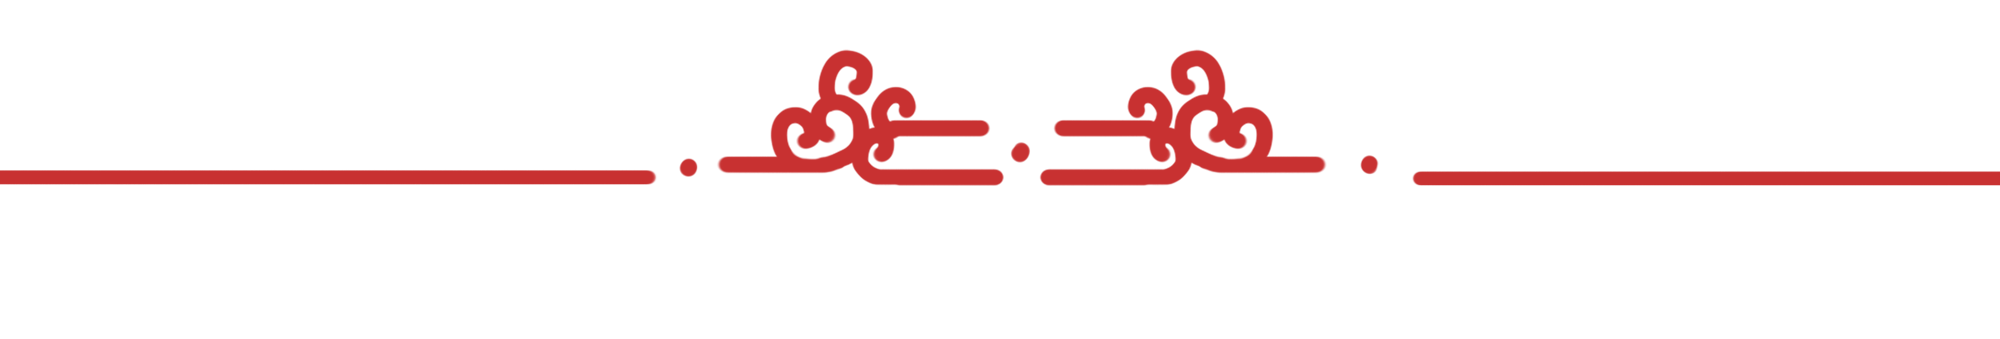

# Nudged Elastic Band

Now, we can optimize the nudged elastic band. The initial and final configurations are the graphene with the vacancy in two different places (https://wiki.fysik.dtu.dk/ase/ase/neb.html)



In [ ]:
#
# attach a specific calculator to this NEB
#

def attach_calc(images, method):
        for image in images[0:n_replica]:  
            image.calc = method()

In [ ]:


def plot_atoms_corrugation(atoms, index):
    """
    Plots the x and y coordinates of an ASE Atoms object in 2D, with z-encoded color.
    The plot maintains equal scaling for x and y axes, has a squared grid, and includes a colorbar.

    Args:
        atoms (ase.Atoms): The ASE Atoms object containing x, y, and z coordinates.

    Returns:
        None (displays the plot)
    """
    # Extract x, y, and z coordinates
    x_coords = atoms.positions[:, 0]
    y_coords = atoms.positions[:, 1]
    z_coords = atoms.positions[:, 2]

    # Calculate the aspect ratio
    L_x = max(x_coords) - min(x_coords)
    L_y = max(y_coords) - min(y_coords)
    aspect_ratio = L_y / L_x

    # Create a scatter plot with z-coordinates determining color
    fig, ax = plt.subplots(figsize=(8, 8 * aspect_ratio))  # Equal scaling for x and y axes
    scatter = ax.scatter(x_coords, y_coords, c=z_coords, cmap='viridis', s=2000)  # Adjust 'cmap' and 's' as desired
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Atoms Object: x-y Coordinates with Z-encoded Color '+str(index))
    plt.grid(True)
    plt.gca().set_aspect('equal')  # Set aspect ratio to be equal
    plt.colorbar(scatter, label='Z-coordinate')  # Add colorbar
    plt.show()



In [ ]:
def print_status_neb(neb, step, optimizer):
    """
    Print NEB optimization status for FIRE(neb).
    Uses neb.emax, neb.emin, neb.imax.
    """


    # energies and forces exist only after first optimizer.step()
    if neb.energies is None:
        print(f"Step {step:4d} | NEB not initialized yet")
        return

    # energy info directly from NEB object
    
    Emax = neb.emax
    imax = neb.imax
    Fmax_target = neb.fmax
    Fmax = neb.get_residual()

    if step % 10 == 0:
        print(
            f"Step {step:4d} | "
            f"Emax = {Emax:.6f} eV (img {imax}) | "
            f"Residual = {Fmax:.4f}"
        )

    if Fmax < Fmax_target:
        print(f"Converged at step {step}: Fmax = {Fmax:.4f} < fmax = {Fmax_target:.4f}")
        return True
    
    return False


In [ ]:
#
# Definitions for plotting
#

def plot_eneneb(images, E0=None, Emid=None, mid_index=None):
    import numpy as np
    import matplotlib.pyplot as plt

    n_replica = len(images)
    ene = np.zeros(n_replica)

    # energie NEB
    for i, image in enumerate(images):
        ene[i] = image.get_potential_energy()

    # shift NEB: prima immagine = 0
    ene_shifted = ene - ene[0]

    # grafico
    plt.figure(figsize=(7,4))
    plt.plot(ene_shifted, "-o", label="NEB")

    # punto DFT iniziale
    if E0 is not None:
        E0_shifted = 0.0
        plt.scatter(-0.2, E0_shifted, color="green", s=80, label="DFT initial")

    # punto DFT metà
    if Emid is not None and E0 is not None and mid_index is not None:
        Emid_shifted = Emid - E0
        plt.scatter(mid_index, Emid_shifted, color="red", s=80, label="DFT TS")

    plt.ylabel("Energy (eV, shifted)")
    plt.xlabel("NEB image #")
    plt.legend()
    plt.grid(True)
    plt.show()

    
    
def plot_atoms_corrugation(atoms, index):
    """
    Plots the x and y coordinates of an ASE Atoms object in 2D, with z-encoded color.
    The plot maintains equal scaling for x and y axes, has a squared grid, and includes a colorbar.

    Args:
        atoms (ase.Atoms): The ASE Atoms object containing x, y, and z coordinates.

    Returns:
        None (displays the plot)
    """
    # Extract x, y, and z coordinates
    x_coords = atoms.positions[:, 0]
    y_coords = atoms.positions[:, 1]
    z_coords = atoms.positions[:, 2]

    # Calculate the aspect ratio
    L_x = max(x_coords) - min(x_coords)
    L_y = max(y_coords) - min(y_coords)
    aspect_ratio = L_y / L_x

    # Create a scatter plot with z-coordinates determining color
    fig, ax = plt.subplots(figsize=(8, 8 * aspect_ratio))  # Equal scaling for x and y axes
    scatter = ax.scatter(x_coords, y_coords, c=z_coords, cmap='viridis', s=2000)  # Adjust 'cmap' and 's' as desired
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Atoms Object: x-y Coordinates with Z-encoded Color '+str(index))
    plt.grid(True)
    plt.gca().set_aspect('equal')  # Set aspect ratio to be equal
    plt.colorbar(scatter, label='Z-coordinate')  # Add colorbar
    plt.show()

    



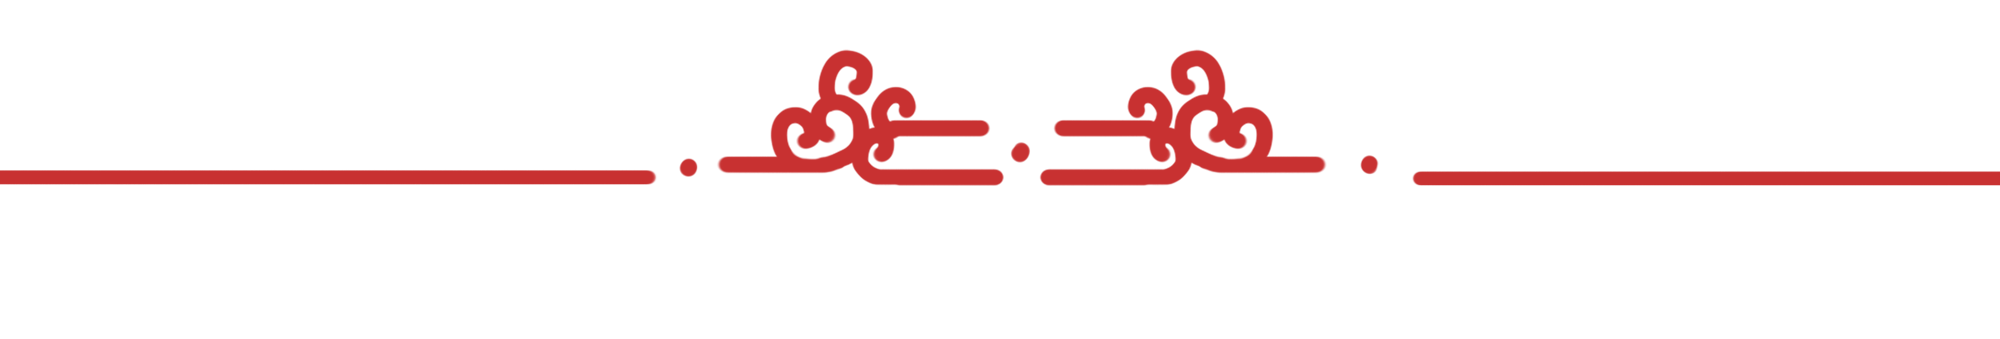

# LCBOP potential
# Preparing the initial NEB: our extremes are 5|9 vacancy states

In [ ]:
from ase.mep import NEB


from ase import io
from ase.optimize import MDMin, BFGS, FIRE, GPMin

n_replica = 11
n_half = int((n_replica-1)/2)

# Read initial and final states:
initial = graph_59_a.copy()
final = graph_59_b.copy()

# Create the list of images
images_l = [initial]

for i in range(n_replica - 2):
    images_l.append(initial.copy())
    
images_l.append(final)


images_l [0].info["title"] = "NEB from 5|9 A to 5|9 B"

    
# Create NEB object
neb_l = NEB(images_l,k=0.1,climb=False)

# Interpolate linearly between initial and final
neb_l.interpolate()


attach_calc (images_l, make_calc_lcbop)

#for image in images:
#    image.cell = initial.get_cell()

for image in images_l[1:n_replica-1]:
    image.rattle (stdev=0.01)  



In [ ]:
#
# Let's plot the energies!
#



plot_eneneb(images_l)

In [ ]:
#
# Let's visualize the initial trajectory...
#

view_trajectory(images_l[0:n_replica],nview=nviewmax-1,nmobile=1)

In [ ]:

neb_l.fmax = 0.02
optimizer = FIRE(neb_l, trajectory='neb.traj', logfile='neb.log')

#
# Running 200 steps of optimization, repeat if necessary until convergence or stagnation
#

for step in range(200):
    optimizer.step()
    if (print_status_neb(neb_l, step, optimizer)):
        break

In [ ]:
#
# Let's plot the energies!
#



plot_eneneb(images_l)
view_trajectory(images_l[0:n_replica],nview=nviewmax-1,nmobile=1,distances=[(0,1),(0,2),(0,3),(0,4)])



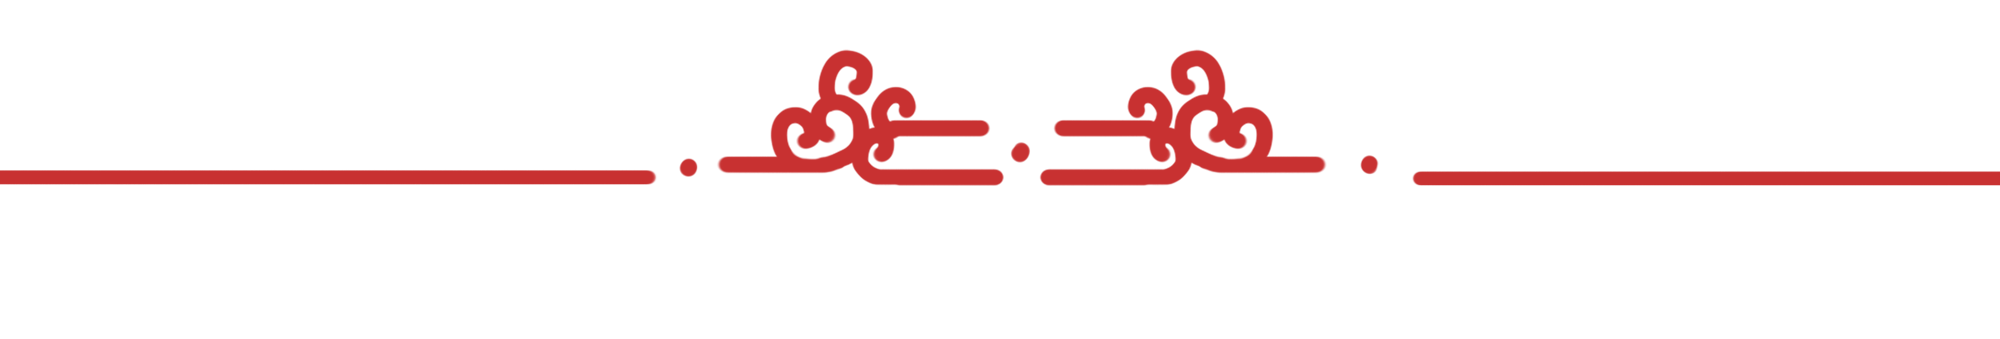


# After optimizing the NEB, we discover that the middle state has a much lower energy with respect to the initial minimum. 
# To try to understand if this is an artifact of the potential, we compute at the ab initio level the energies at the initial and intermediate state.


## Setting up a DFT calculator, and computing the energies.
### To follow the calculations, open a terminal and give in the same directory `tail -f cp2k.out `

In [ ]:
#
# Calculator for DFT
#

inp_pbe = """
&FORCE_EVAL
  &DFT
    BASIS_SET_FILE_NAME BASIS_MOLOPT
    &QS
      EPS_DEFAULT 1.0E-8
    &END QS
    
    
    &SCF
          SCF_GUESS RESTART
      EPS_SCF 1.0E-4
    
    
      &OT
        PRECONDITIONER  FULL_SINGLE_INVERSE
        MINIMIZER  CG
      &END
      &OUTER_SCF
        MAX_SCF 10
        EPS_SCF 1.0E-4
      &END
         &PRINT
            &RESTART
               &EACH
                  QS_SCF 500
               &END
            ADD_LAST NUMERIC
            &END
         &END
      &END SCF

    &XC
      &XC_FUNCTIONAL PBE
      &END XC_FUNCTIONAL
    &END XC
  &END DFT
  &SUBSYS
    &KIND C
      BASIS_SET SZV-MOLOPT-GTH
      POTENTIAL GTH-PBE-q4
    &END KIND
  &END SUBSYS
&END FORCE_EVAL
&GLOBAL
  RUN_TYPE ENERGY
&END GLOBAL
"""

def make_calc_dft():
    return CP2K(inp=inp_pbe,command="env OMP_NUM_THREADS=2  /usr/bin/cp2k_shell.psmp",basis_set_file=None,potential_file="POTENTIAL",force_eval_method='QS',basis_set=None,pseudo_potential=None,cutoff=2000,print_level='LOW',stress_tensor=False,max_scf=None,xc=None)

In [ ]:
pbe_a = graph_59_a.copy()

pbe_a.set_pbc([True,True,True])  # To make electrostatics more efficient
my = pbe_a.get_cell()
my[2,2] = 5
pbe_a.set_cell(my)
pbe_a.calc = make_calc_dft()

pbe_b = graph_59_b.copy()

pbe_b.set_pbc([True,True,True])  # To make electrostatics more efficient
my = pbe_b.get_cell()
my[2,2] = 5
pbe_b.set_cell(my)
pbe_b.calc = make_calc_dft()

pbe_ts = images_l[5].copy()
pbe_ts.set_pbc([True,True,True])  # To make electrostatics more efficient
my = pbe_ts.get_cell()
my[2,2] = 5
pbe_ts.set_cell(my)
pbe_ts.calc = make_calc_dft()

In [ ]:

pbe_ts.get_potential_energy()

In [ ]:

pbe_a.get_potential_energy()

In [ ]:
plot_eneneb (images_l,E0=pbe_a.get_potential_energy(),Emid=pbe_ts.get_potential_energy(),mid_index=5)


# We note that the TS has an higher energy that the extremes. This is good. Of course by optimizing the NEB in DFT one could lower the barrier to the low values found in the paper. 
# 

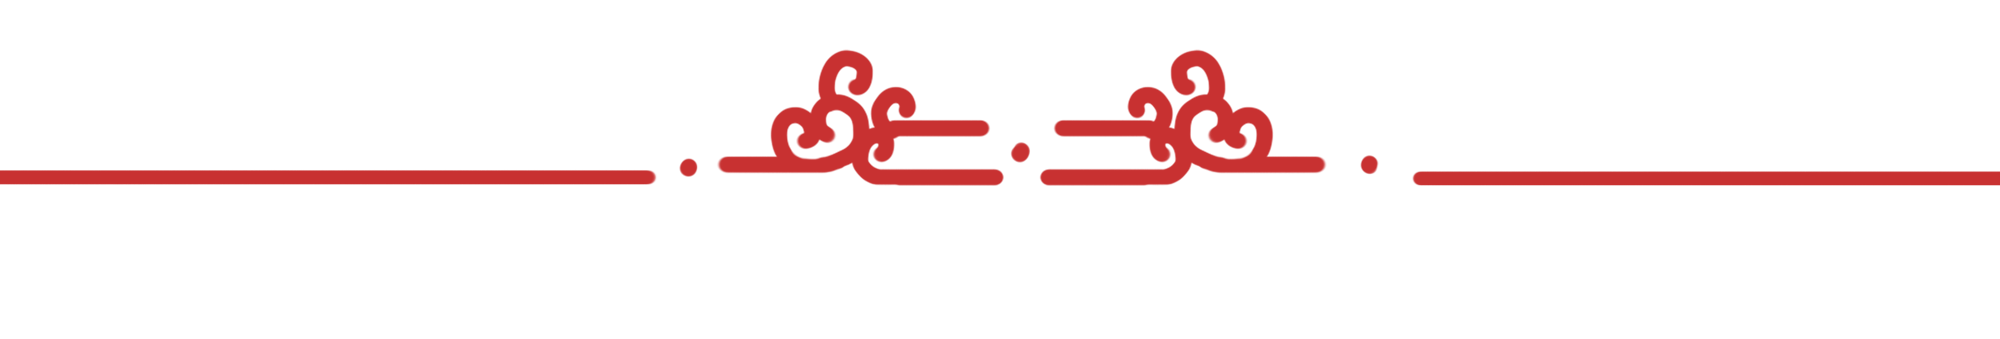

# TERSOFF potential
# Preparing the initial NEB

In [ ]:



# Read initial and final states:
initial = graph_59_a.copy()
initial.calc = make_calc_tersoff()
final = graph_59_b.copy()
final.calc = make_calc_tersoff()

# Create the list of images
images_t = [initial]

for i in range(n_replica - 2):
    images_t.append(initial.copy())
    
images_t.append(final)


images_t [0].info["title"] = "NEB from 5|9 A to 5|9 B (tersoff)"

    
# Create NEB object
neb_t = NEB(images_t,k=0.1,climb=False)

# Interpolate linearly between initial and final
neb_t.interpolate()


attach_calc (images_t, make_calc_tersoff)

#for image in images:
#    image.cell = initial.get_cell()

for image in images_t[1:n_replica-1]:
    image.rattle (stdev=0.01)  



In [ ]:
#
# Let's plot the energies!
#



plot_eneneb(images_t)

In [ ]:
#
# Let's visualize the initial trajectory...
#

view_trajectory(images_t[0:n_replica],nview=nviewmax-1,nmobile=1)

In [ ]:

neb_t.fmax = 0.02
optimizer = FIRE(neb_t, trajectory='neb.traj', logfile='neb.log')

for step in range(200):
    optimizer.step()
    if (print_status_neb(neb_t, step, optimizer)):
        break

In [ ]:
#
# Let's plot the energies after optimization
#



plot_eneneb(images_t)
view_trajectory(images_t[0:n_replica],nview=nviewmax-1,nmobile=1)

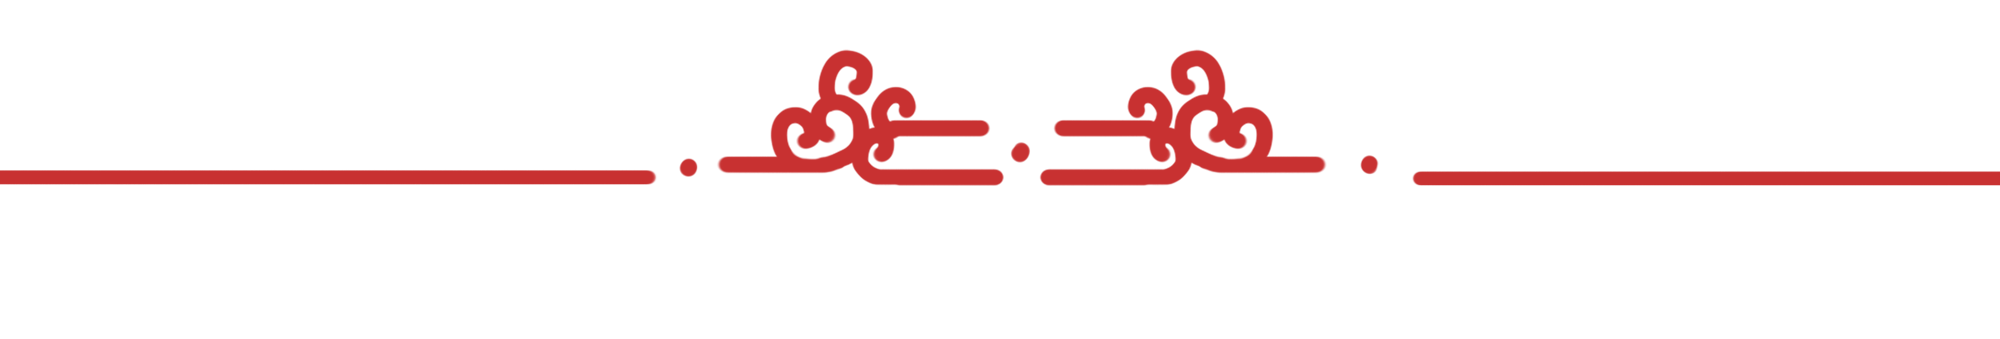


# In the case of the tersoff potential, the problem is that the 5|9 state is not a minimum, so the system passes through the D3H state (image 1)
# Let us check with the ab initio calculation: we compute state a (image 0), state D3H (image 1) and the transition state from the Tersoff.

In [ ]:
pbe_ts = images_t[5].copy()
pbe_ts.set_pbc([True,True,True])  # To make electrostatics more efficient
my = pbe_ts.get_cell()
my[2,2] = 5
pbe_ts.set_cell(my)
pbe_ts.calc = make_calc_dft()

In [ ]:
pbe_ts.get_potential_energy()

In [ ]:
plot_eneneb (images_t,E0=pbe_a.get_potential_energy(),Emid=pbe_ts.get_potential_energy(),mid_index=5)

In [ ]:
pbe_1 = images_t[1].copy()
pbe_1.set_pbc([True,True,True])  # To make electrostatics more efficient
my = pbe_1.get_cell()
my[2,2] = 5
pbe_1.set_cell(my)
pbe_1.calc = make_calc_dft()

In [ ]:
pbe_1.get_potential_energy()

In [ ]:
plot_eneneb (images_t,E0=pbe_a.get_potential_energy(),Emid=pbe_1.get_potential_energy(),mid_index=1)

### D3H is higher in energy than 5|9 (good), the transition state is higher but too high. 
### The tersoff potential seems not to be very good for the intermediate structures.

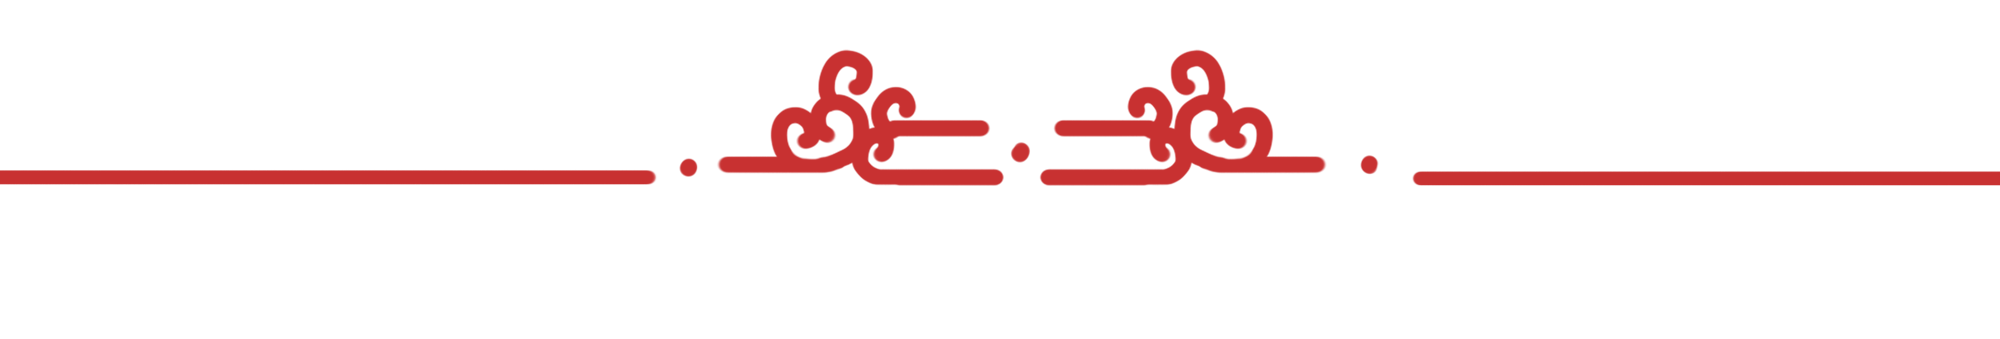

# Analysis of corrugation

In [ ]:



import matplotlib.pyplot as plt
import ipywidgets as ipw
from IPython.display import clear_output
output = ipw.Output()
display(output)

In [ ]:
#
# change the images_l to images_t in the case of tersoff!
# Movie of the corrugations
#

# Example usage:
import time
i = 0
for image in images_l[0:n_replica]:  
    time.sleep(1)
    with output:
        clear_output()
        plot_atoms_corrugation(image[0:lastindex_v],i)
    i = i+1


In [ ]:
#
# change the images_l to images_t in the case of tersoff!
# Corrugation of a specific image
#


plot_atoms_corrugation(images_l[n_half][0:lastindex_v],n_half)

#
# In principle we should compare the corrugation with the result found in the paper... but our system size is way to small :-)
#

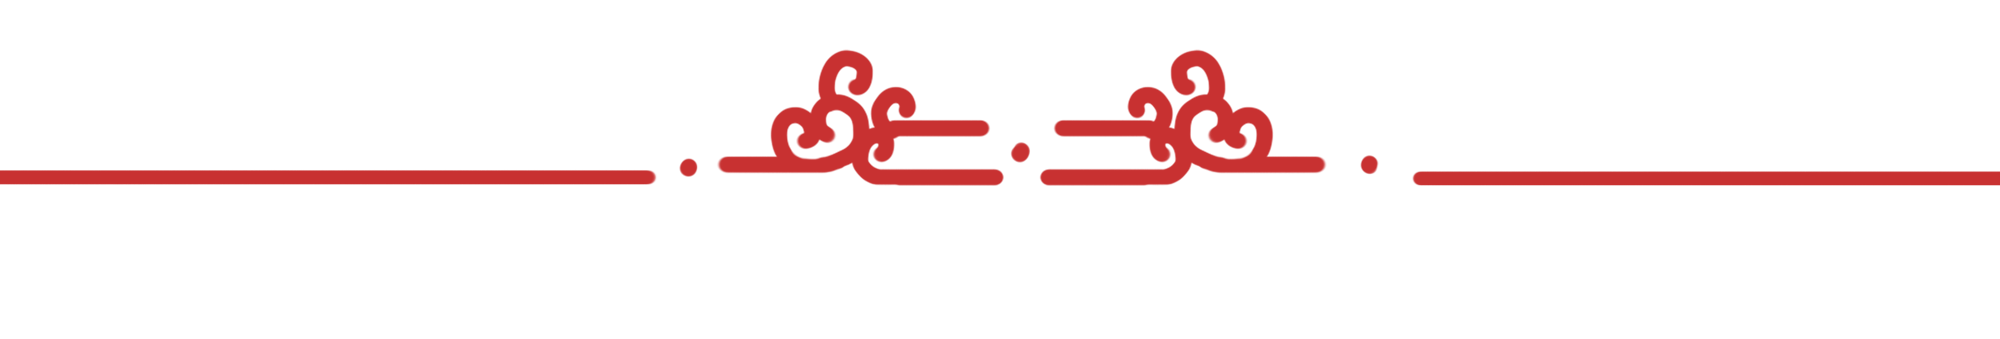

# Questions:

1. Test the same exercise with `flat = True` if it was `False` before, and note the differences in barrier. Note also the "corrugation" (is there any)?
2. Increase the number of replica to 23 and check the differences 
3. Recompute the ab initio energy for the central replica (which one you choose?), replot the results.